# Day 5 · 时效与服务质量 · 海豚生 🐬

> **德邦经营方向 · 第 5 天练习**  
> 目标：算准时率、画散点图、找出超时最严重的区域，给出改进建议

---

## 今天你要学会

| 技能 | 对应德邦场景 |
|------|-------------|
| 准时率计算 | `delivery_days ≤ 3` 的运单占比 |
| 散点图 | 时效 vs 满意度，有没有关系？ |
| 客诉率分析 | 哪些区域/客户投诉多？ |
| 服务质量结论 | 从 KPI 到「该改哪个环节」 |

## 德邦服务质量 3 指标

| 指标 | 基准 | 越低/高越好 |
|------|------|-----------|
| **准时率** | ≥ 75% | 越高越好 |
| **平均满意度** | ≥ 4.0 分 | 越高越好 |
| **客诉率** | ≤ 3% | 越低越好 |

## 对标案例

- `散点图.ipynb` — 两个变量关系
- `泰坦尼克号.ipynb` — 分组对比思路

**文件名：** `Day5_Service_Quality.ipynb`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

SLA_DAYS = 3          # 时效承诺：3 天内送达
BENCHMARK_ONTIME = 75.0   # 准时率基准(%)
BENCHMARK_SAT = 4.0       # 满意度及格线
BENCHMARK_COMPLAINT = 3.0 # 客诉率上限(%)

df = pd.read_csv("data/orders.csv")
df["准时"] = df["delivery_days"] <= SLA_DAYS

print(f"数据就绪：{len(df)} 条运单 ✅")
df[["order_id", "region", "delivery_days", "satisfaction", "is_complaint", "准时"]].head(5)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\32669\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\32669\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\32669\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\32669\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\32669\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\32669\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\32669\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\32669\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\32669\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\32669\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found

数据就绪：150 条运单 ✅


,order_id,region,delivery_days,satisfaction,is_complaint,准时
0,ORD2024110001,华东,1,3,0,True
1,ORD2025010002,西南,2,2,1,True
2,ORD2024020003,华北,4,5,0,False
3,ORD2024120004,华东,4,4,0,False
4,ORD2024120005,华东,2,4,0,True


---
## 第 1 步：算 3 个服务质量 KPI ⭐

In [2]:
on_time_rate = df["准时"].mean() * 100
avg_satisfaction = df["satisfaction"].mean()
complaint_rate = df["is_complaint"].mean() * 100

def status(val, benchmark, higher_is_better=True):
    ok = val >= benchmark if higher_is_better else val <= benchmark
    return "✅ 达标" if ok else "⚠️ 未达标"

print("=" * 45)
print("  服务质量 KPI · 海豚生")
print("=" * 45)
print(f"  准时率:     {on_time_rate:.1f}%  (基准 ≥{BENCHMARK_ONTIME}%)  {status(on_time_rate, BENCHMARK_ONTIME)}")
print(f"  平均满意度: {avg_satisfaction:.2f} 分 (基准 ≥{BENCHMARK_SAT})  {status(avg_satisfaction, BENCHMARK_SAT)}")
print(f"  客诉率:     {complaint_rate:.1f}%  (基准 ≤{BENCHMARK_COMPLAINT}%)  {status(complaint_rate, BENCHMARK_COMPLAINT, False)}")
print("=" * 45)

  服务质量 KPI · 海豚生
  准时率:     74.0%  (基准 ≥75.0%)  ⚠️ 未达标
  平均满意度: 3.97 分 (基准 ≥4.0)  ⚠️ 未达标
  客诉率:     14.0%  (基准 ≤3.0%)  ⚠️ 未达标


---
## 第 2 步：各区域准时率对比 — 找出拖后腿的区

In [8]:
region_svc = df.groupby("region").agg(
    准时率=("准时", "mean"),
    平均满意度=("satisfaction", "mean"),
    客诉率=("is_complaint", "mean"),
    单量=("order_id", "count"),
).reset_index()

region_svc["准时率(%)"] = (region_svc["准时率"] * 100).round(1)
region_svc["客诉率(%)"] = (region_svc["客诉率"] * 100).round(1)
region_svc["平均满意度"] = region_svc["平均满意度"].round(2)
region_svc = region_svc.sort_values("准时率(%)")

print("准时率最低的两个区域：")
worst2 = region_svc.head(2)
for _, row in worst2.iterrows():
    print(f"  ⚠️ {row['region']}区: 准时率 {row['准时率(%)']}%，满意度 {row['平均满意度']}，客诉率 {row['客诉率(%)']}%")

region_svc[["region", "准时率(%)", "平均满意度", "客诉率(%)", "单量"]]

准时率最低的两个区域：
  ⚠️ 华南区: 准时率 68.6%，满意度 3.89，客诉率 20.0%
  ⚠️ 华中区: 准时率 70.0%，满意度 3.93，客诉率 13.3%


,region,准时率(%),平均满意度,客诉率(%),单量
3,华南,68.6,3.89,20.0,35
1,华中,70.0,3.93,13.3,30
0,华东,72.4,4.14,6.9,29
4,西南,72.7,3.91,15.2,33
2,华北,91.3,4.00,13.0,23


---
## 第 3 步：散点图 — 时效 vs 满意度 📈

**问题：** 送得越慢，客户越不满意吗？

- X 轴 = 实际时效天数
- Y 轴 = 满意度评分
- 红色虚线 = SLA 3 天

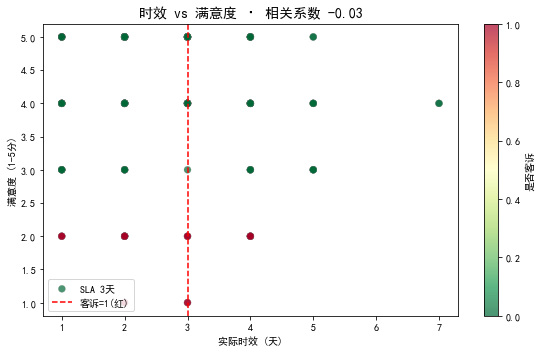

相关系数: -0.032（负值 = 越慢越不满意，越接近0 = 关系越弱）


In [4]:
corr = df["delivery_days"].corr(df["satisfaction"])

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df["delivery_days"], df["satisfaction"],
    c=df["is_complaint"], cmap="RdYlGn_r", alpha=0.7, s=50, edgecolors="gray", linewidth=0.3,
)
ax.axvline(x=SLA_DAYS, color="red", linestyle="--", linewidth=1.5, label=f"SLA {SLA_DAYS} 天")

ax.set_xlabel("实际时效 (天)")
ax.set_ylabel("满意度 (1-5分)")
ax.set_title(f"时效 vs 满意度 · 相关系数 {corr:.2f}", fontsize=14, fontweight="bold")
ax.legend(["SLA 3天", "客诉=1(红)", "客诉=0(绿)"], loc="lower left")
plt.colorbar(scatter, label="是否客诉")
plt.tight_layout()
plt.show()

print(f"相关系数: {corr:.3f}（负值 = 越慢越不满意，越接近0 = 关系越弱）")

---
## 第 4 步：区域准时率柱状图

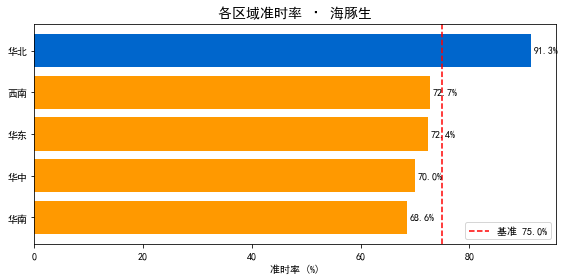

In [5]:
region_plot = region_svc.sort_values("准时率(%)", ascending=True)
colors = ["#FF9900" if v < BENCHMARK_ONTIME else "#0066CC" for v in region_plot["准时率(%)"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(region_plot["region"], region_plot["准时率(%)"], color=colors)
ax.axvline(x=BENCHMARK_ONTIME, color="red", linestyle="--", label=f"基准 {BENCHMARK_ONTIME}%")

for _, row in region_plot.iterrows():
    ax.text(row["准时率(%)"] + 0.5, row["region"], f"{row['准时率(%)']}%", va="center", fontsize=10)

ax.set_title("各区域准时率 · 海豚生", fontsize=14, fontweight="bold")
ax.set_xlabel("准时率 (%)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 第 5 步：客诉明细 — 谁在被投诉？

In [6]:
complaints = df[df["is_complaint"] == 1]
print(f"共 {len(complaints)} 单客诉（客诉率 {complaint_rate:.1f}%）\n")

if len(complaints) > 0:
    by_region = complaints.groupby("region").size().sort_values(ascending=False)
    by_customer = complaints.groupby("customer_name").size().sort_values(ascending=False).head(5)
    print("客诉最多的区域：")
    print(by_region.to_string())
    print("\n客诉最多的客户 TOP5：")
    print(by_customer.to_string())
else:
    print("暂无客诉 ✅")

共 21 单客诉（客诉率 14.0%）

客诉最多的区域：
region
华南    7
西南    5
华中    4
华北    3
华东    2

客诉最多的客户 TOP5：
customer_name
华为供应链    4
格力物流     4
海尔智家     4
王商户      3
美的物流     2


---
## 第 6 步：写服务质量诊断结论 ✏️

In [9]:
# 第 6 步：根据实际 KPI 生成服务质量诊断报告
worst_regions = region_svc.sort_values("准时率(%)").head(2)

my_report = f"""
【数据发现】
- 整体准时率 {on_time_rate:.1f}%，{'高于' if on_time_rate >= BENCHMARK_ONTIME else '低于'} {BENCHMARK_ONTIME:.0f}% 基准
- 平均满意度 {avg_satisfaction:.2f} 分，{'高于' if avg_satisfaction >= BENCHMARK_SAT else '低于'} {BENCHMARK_SAT:.1f} 分及格线
- 客诉率 {complaint_rate:.1f}%，{'低于' if complaint_rate <= BENCHMARK_COMPLAINT else '高于'} {BENCHMARK_COMPLAINT:.0f}% 上限
- 准时率最低区域：{worst_regions.iloc[0]['region']}区（{worst_regions.iloc[0]['准时率(%)']:.1f}%）、{worst_regions.iloc[1]['region']}区（{worst_regions.iloc[1]['准时率(%)']:.1f}%）

【经营含义】
服务质量整体仍有明显短板，尤其是准时率和客诉率偏差较大，直接影响客户信任和后续复购。重点区域的时效问题会放大客户流失风险。

【改进动作 — 3 条可执行建议】
1. 优先梳理 {worst_regions.iloc[0]['region']}区和 {worst_regions.iloc[1]['region']}区的超时线路，缩短转运和派送滞后。
2. 对满意度较低的订单和高客诉客户做 48 小时内回访，收集问题原因并闭环处理。
3. 将准时率低的区域与华北区等标杆区域做对标，复制其高效派送和服务流程。
"""

print(my_report)


【数据发现】
- 整体准时率 74.0%，低于 75% 基准
- 平均满意度 3.97 分，低于 4.0 分及格线
- 客诉率 14.0%，高于 3% 上限
- 准时率最低区域：华南区（68.6%）、华中区（70.0%）

【经营含义】
服务质量整体仍有明显短板，尤其是准时率和客诉率偏差较大，直接影响客户信任和后续复购。重点区域的时效问题会放大客户流失风险。

【改进动作 — 3 条可执行建议】
1. 优先梳理 华南区和 华中区的超时线路，缩短转运和派送滞后。
2. 对满意度较低的订单和高客诉客户做 48 小时内回访，收集问题原因并闭环处理。
3. 将准时率低的区域与华北区等标杆区域做对标，复制其高效派送和服务流程。



---
## 🎯 进阶小练习

1. 算 **超时运单**（delivery_days > 3）的平均满意度 vs **准时运单**
2. 哪些 **A 类客户**（Day 3）有客诉？（合并 `customer_stats`）
3. 按 **product_type** 分组看准时率 — 哪个产品最慢？

<details>
<summary>💡 参考答案</summary>

```python
# 1. 超时 vs 准时 满意度
print(df.groupby("准时")["satisfaction"].mean())

# 2. 客诉 + 客户名
print(df[df["is_complaint"]==1]["customer_name"].value_counts())

# 3. 产品准时率
print(df.groupby("product_type")["准时"].mean().sort_values().apply(lambda x: f"{x*100:.1f}%"))
```
</details>

---

## ✅ Day 5 完成标准

- [ ] 3 个服务质量 KPI 算出来了
- [ ] 找出准时率最低的 2 个区域
- [ ] 散点图 + 区域准时率柱图跑通
- [ ] 写了 3 条改进建议

**预期结果参考：**
| KPI | 数值 | 状态 |
|-----|------|------|
| 准时率 | 74.0% | ⚠️ 略低于 75% |
| 平均满意度 | 3.97 分 | ⚠️ 略低于 4.0 |
| 客诉率 | 14.0% | ⚠️ 远高于 3% |
| 最差区域 | **西南** 68.6%、**华北** 70.0% | 需重点改进 |
| 最好区域 | **华中** 91.3% | 可标杆复制 |

**明天 Day 6：** 月度趋势与预警 — 环比分析 + 紧急复盘建议 📉

In [10]:
# 进阶小练习：直接计算结果

# 1. 超时运单 vs 准时运单的平均满意度
print("超时运单 vs 准时运单平均满意度：")
print(df.groupby("准时")["satisfaction"].mean().round(2))

# 2. A 类客户中有客诉的客户（需要先从 Day 3 的 customer_stats 结果合并）
try:
    a_names = customer_stats[customer_stats["ABC"] == "A"]["customer_name"]
    complaints_a = df[(df["customer_name"].isin(a_names)) & (df["is_complaint"] == 1)]
    print("\nA 类客户中有客诉的客户：")
    print(complaints_a.groupby("customer_name").size().sort_values(ascending=False))
except NameError:
    print("\n请先运行 Day 3 的客户 ABC 分层步骤，再执行这个单元格。")

# 3. 按 product_type 分组看准时率
product_on_time = df.groupby("product_type")["准时"].mean().sort_values()
print("\n各产品类型准时率：")
print((product_on_time * 100).round(1).astype(str) + "%")

超时运单 vs 准时运单平均满意度：
准时
False    3.79
True     4.03
Name: satisfaction, dtype: float64

请先运行 Day 3 的客户 ABC 分层步骤，再执行这个单元格。

各产品类型准时率：
product_type
整车运输     60.0%
同城当日达    66.7%
仓储配送     70.6%
大件快递     70.8%
精准汽运     78.9%
精准卡航     79.1%
Name: 准时, dtype: object
